In [55]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
from xgboost import XGBRegressor
import joblib


#### reading csv data

In [56]:
df = pd.read_csv("../data/processed/house_data.csv")

In [57]:
df.head()

,location,area,bedrooms,bathrooms,parking,price
0,Pokhara,1710,3,2,2,20850000
1,Lahan,1262,3,2,2,18150000
2,Pokhara,1786,3,2,2,22350000
3,Itahari,1717,3,1,3,14000000
4,Banepa,2198,4,2,3,25000000


In [58]:
df.shape

(1460, 6)

In [59]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   location   1460 non-null   str  
 1   area       1460 non-null   int64
 2   bedrooms   1460 non-null   int64
 3   bathrooms  1460 non-null   int64
 4   parking    1460 non-null   int64
 5   price      1460 non-null   int64
dtypes: int64(5), str(1)
memory usage: 79.6 KB


In [60]:
df.describe()

,area,bedrooms,bathrooms,parking,price
count,1460.000000,1460.000000,1460.000000,1460.000000,1.460000e+03
mean,1515.463699,2.866438,1.565068,1.767123,1.809212e+07
std,525.480383,0.815778,0.550916,0.747315,7.944250e+06
min,334.000000,0.000000,0.000000,0.000000,3.490000e+06
25%,1129.500000,2.000000,1.000000,1.000000,1.299750e+07
50%,1464.000000,3.000000,2.000000,2.000000,1.630000e+07
75%,1776.750000,3.000000,2.000000,2.000000,2.140000e+07
max,5642.000000,8.000000,3.000000,4.000000,7.550000e+07


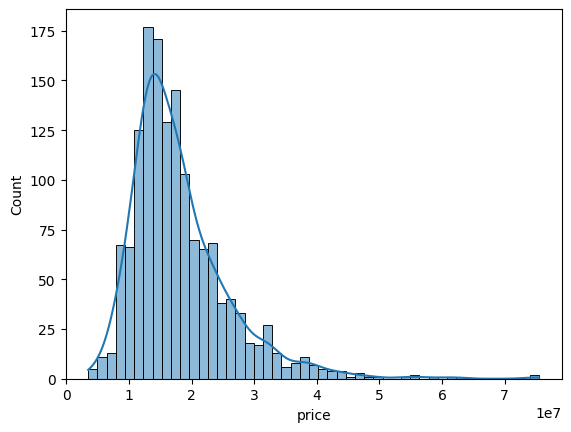

In [61]:
sns.histplot(df["price"], kde=True)

plt.show()

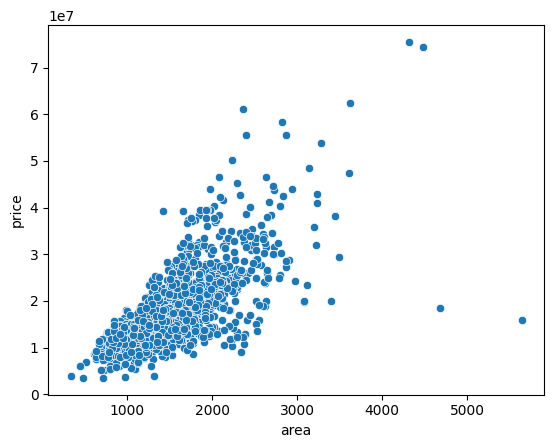

In [62]:
sns.scatterplot(
    x=df["area"],
    y=df["price"]
)

plt.show()

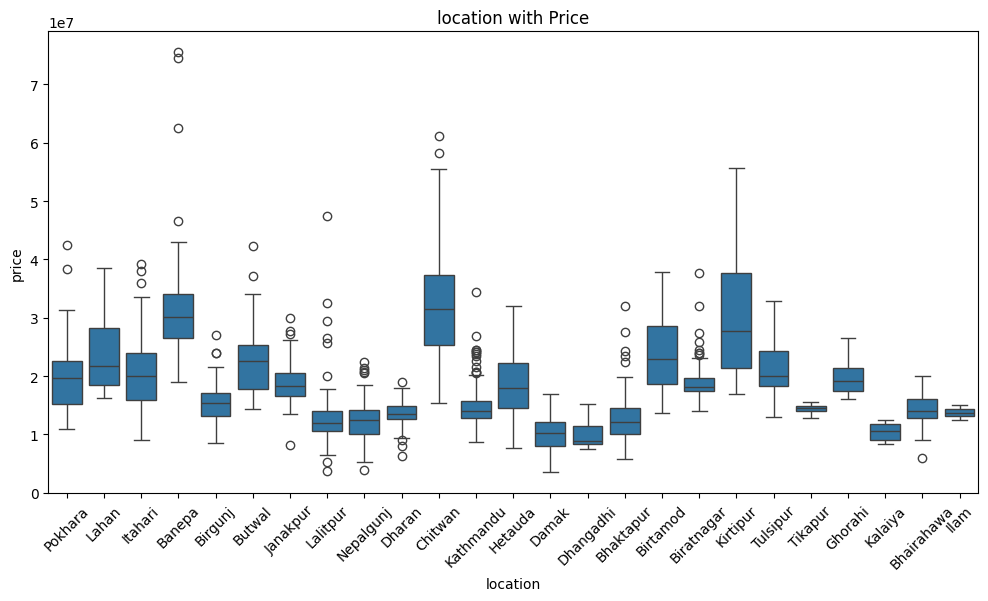

In [63]:
plt.figure(figsize=(12,6))

sns.boxplot(
    x=df["location"],
    y=df["price"]
)

plt.xticks(rotation=45)
plt.title("location with Price")
plt.xlabel("location")
plt.ylabel("price")
plt.show()

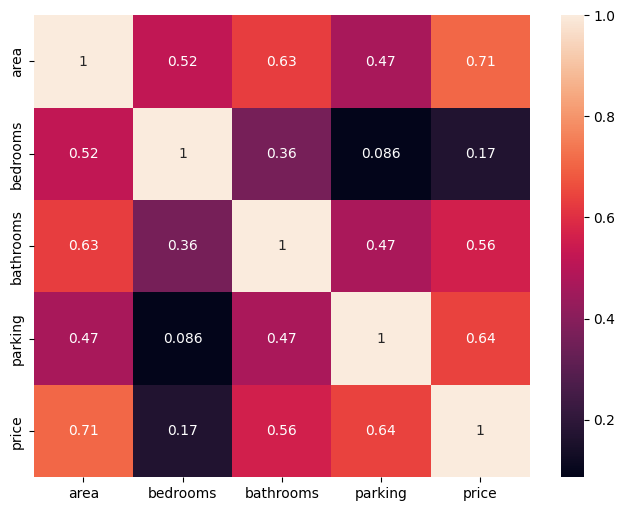

In [64]:
numeric_df = df.select_dtypes(include=np.number)

corr = numeric_df.corr()

plt.figure(figsize=(8,6))

sns.heatmap(corr, annot=True)

plt.show()

In [65]:
df_encoded = pd.get_dummies(
    df,
    columns=["location"],
    drop_first=True,dtype=int
)

In [66]:
X = df_encoded.drop("price", axis=1)

y = df_encoded["price"]
joblib.dump(X.columns.tolist(), "../src/columns.pkl")

['../src/columns.pkl']

In [67]:


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    
)


#### Linear regression model

In [68]:
lr = LinearRegression()

lr.fit(X_train, y_train)
lr_preds = lr.predict(X_test)
print("MAE:", mean_absolute_error(y_test, lr_preds))

print("RMSE:", np.sqrt(mean_squared_error(y_test, lr_preds)))

print("R2:", r2_score(y_test, lr_preds))

MAE: 2671657.5381359914
RMSE: 4048212.7645951766
R2: 0.7863451156474195


### randomforestregressor

In [69]:
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)

print("R2:", r2_score(y_test, rf_preds))

R2: 0.8694756737323075


### XGBRegressor

In [70]:
xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)

xgb.fit(X_train, y_train)
xgb_preds = xgb.predict(X_test)

print("R2:", r2_score(y_test, xgb_preds))

R2: 0.870450496673584


comparing these regression we can conclude that xgbregressor is best among these models 

In [71]:
joblib.dump(
    xgb,
    "../src/model1.pkl"
)

print("Model saved!")

Model saved!


In [72]:
df['location'].unique().tolist()

['Pokhara',
 'Lahan',
 'Itahari',
 'Banepa',
 'Birgunj',
 'Butwal',
 'Janakpur',
 'Lalitpur',
 'Nepalgunj',
 'Dharan',
 'Chitwan',
 'Kathmandu',
 'Hetauda',
 'Damak',
 'Dhangadhi',
 'Bhaktapur',
 'Birtamod',
 'Biratnagar',
 'Kirtipur',
 'Tulsipur',
 'Tikapur',
 'Ghorahi',
 'Kalaiya',
 'Bhairahawa',
 'Ilam']